In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
# Load the Iris dataset
iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


In [3]:
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nDataset shape:")
print(iris.data.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


In [4]:
# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species names
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["species"].value_counts())

Dataset Shape:
(150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


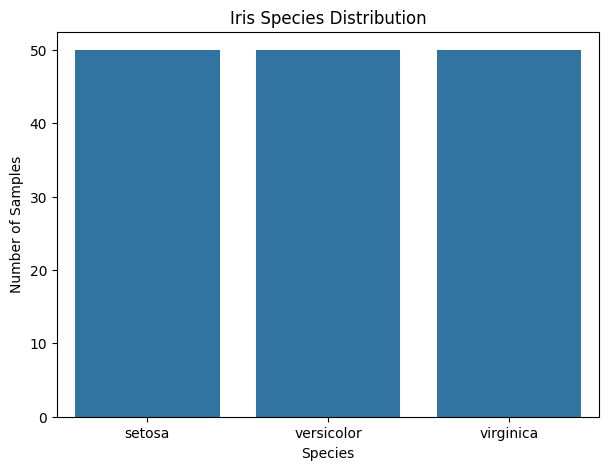

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="species")

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

<Figure size 1200x800 with 0 Axes>

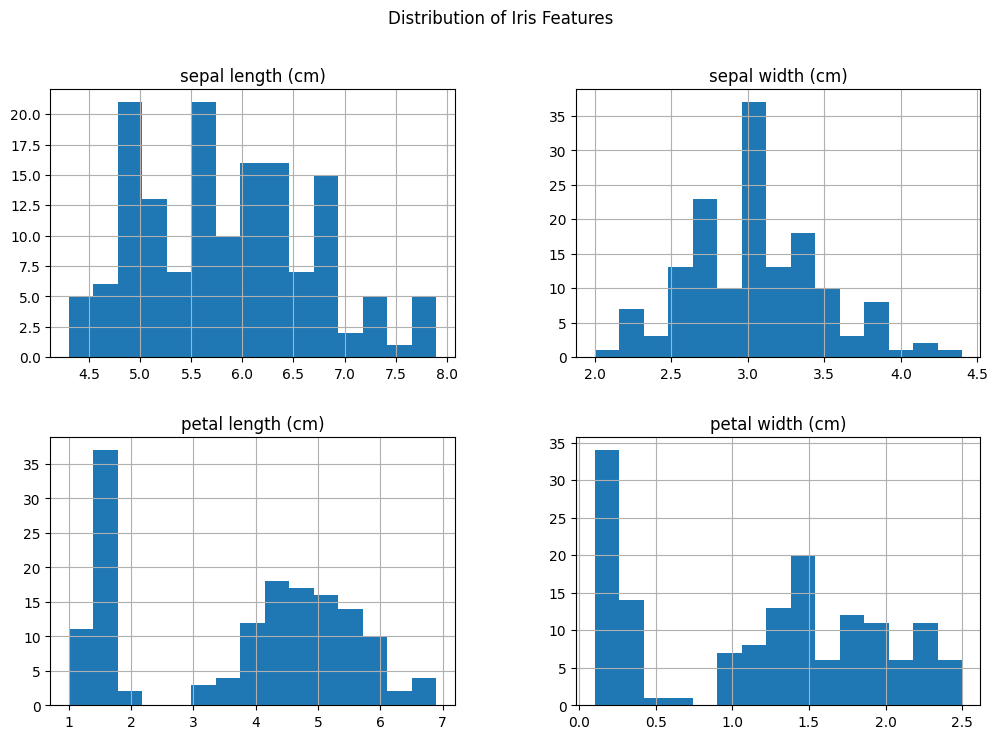

In [7]:
plt.figure(figsize=(12, 8))

df[iris.feature_names].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Distribution of Iris Features")

plt.show()

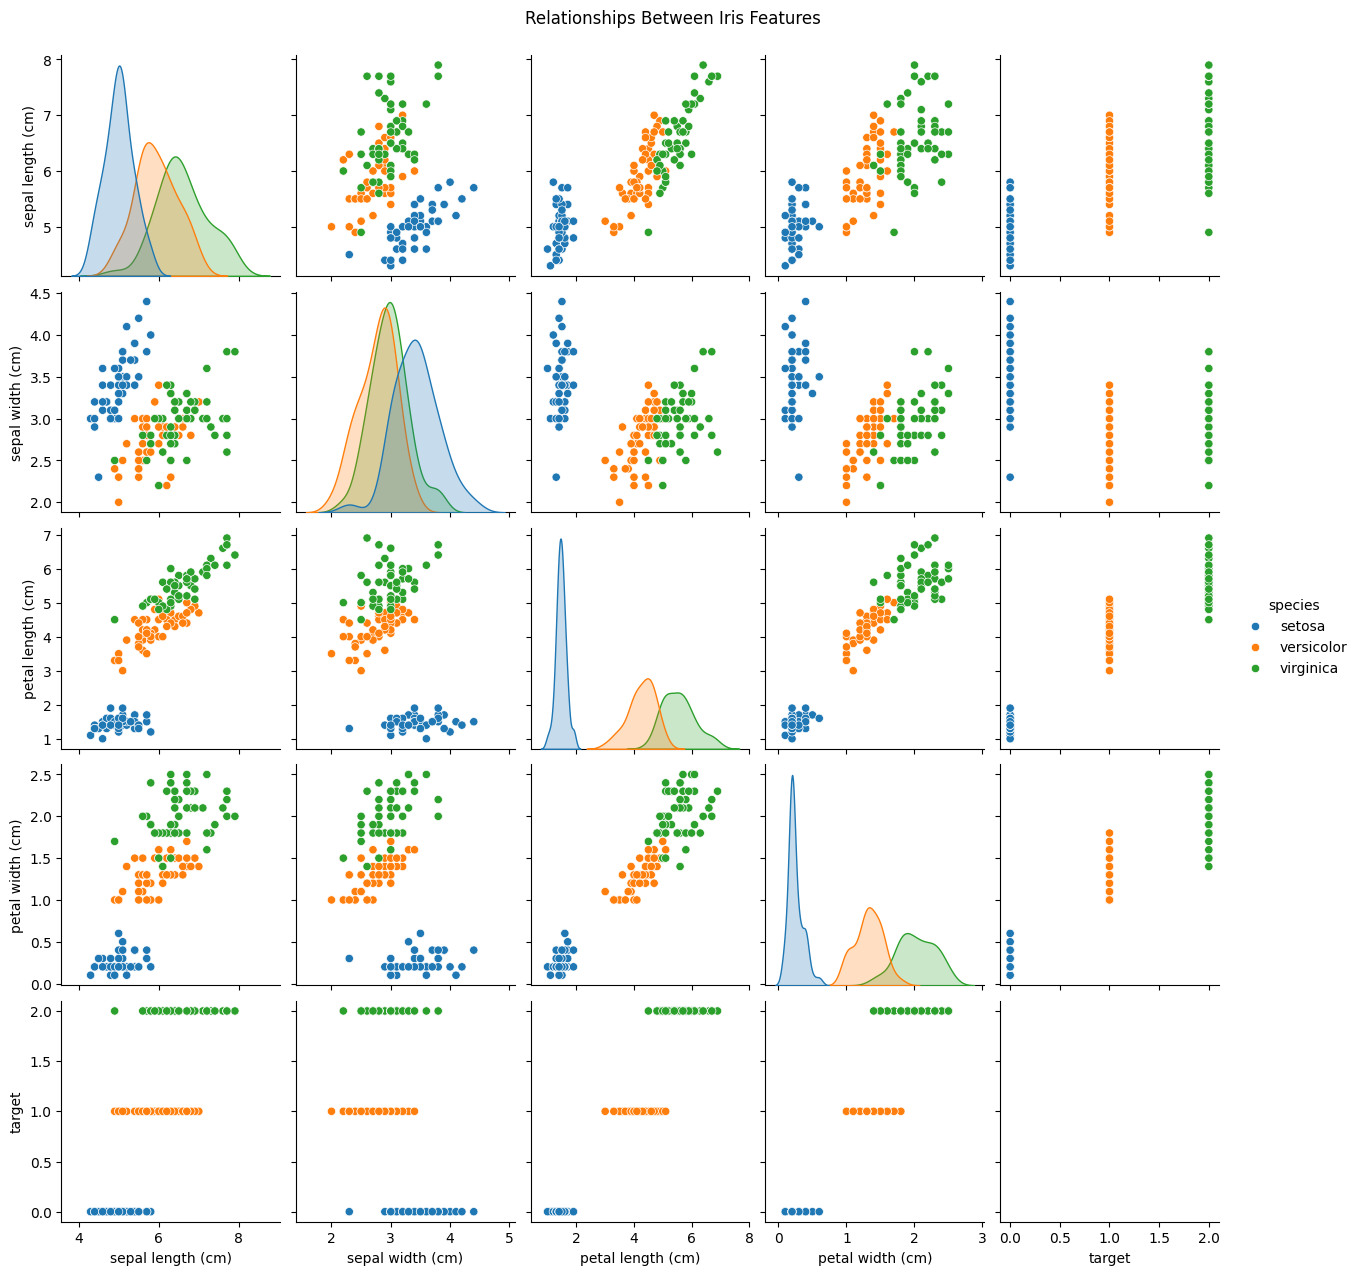

In [8]:
sns.pairplot(
    df,
    hue="species"
)

plt.suptitle(
    "Relationships Between Iris Features",
    y=1.02
)

plt.show()

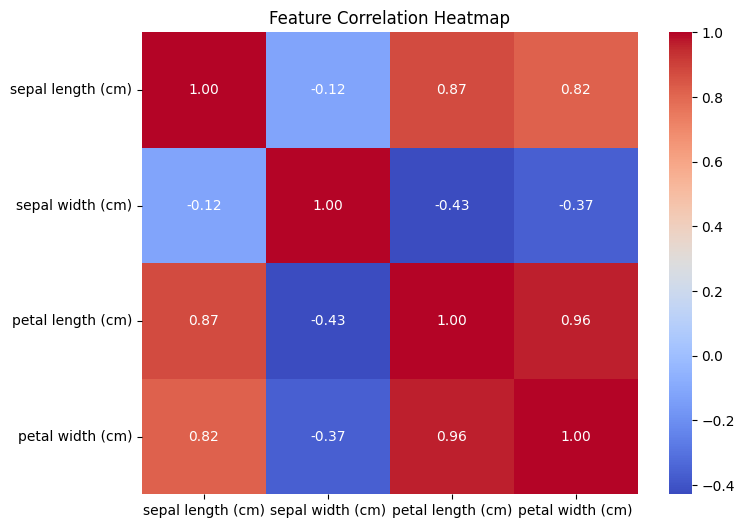

In [9]:
plt.figure(figsize=(8, 6))

correlation = df[iris.feature_names].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [10]:
# Separate input features (X) and target (y)

X = df[iris.feature_names]
y = df["target"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create the scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
# Make predictions on the test data
y_pred = logistic_model.predict(X_test_scaled)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1-Score  : 0.9333


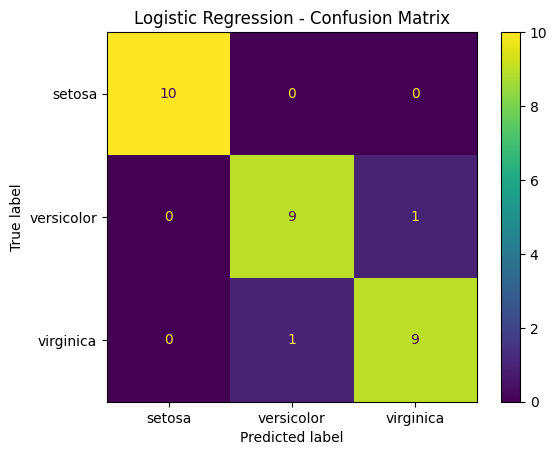

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [17]:
# Make predictions using Decision Tree
dt_pred = decision_tree_model.predict(X_test)

print("Decision Tree Predictions:")
print(dt_pred)

Decision Tree Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [18]:
# Calculate Decision Tree metrics

dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average="weighted"
)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1-Score  : {dt_f1:.4f}")

Decision Tree Performance
-------------------------
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1-Score  : 0.9333


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [20]:
# Make predictions using Random Forest
rf_pred = random_forest_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred)

Random Forest Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


In [21]:
# Calculate Random Forest metrics

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

Random Forest Performance
-------------------------
Accuracy  : 0.9000
Precision : 0.9024
Recall    : 0.9000
F1-Score  : 0.8997


In [22]:
# Create model comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        dt_f1,
        rf_f1
    ]
})

# Display results as percentages
results_display = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,93.33,93.33,93.33,93.33
1,Decision Tree,93.33,93.33,93.33,93.33
2,Random Forest,90.00,90.24,90.00,89.97


In [24]:
# Custom flower measurements
custom_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

# Scale the custom input
custom_flower_scaled = scaler.transform(custom_flower)

# Make prediction
custom_prediction = logistic_model.predict(custom_flower_scaled)

# Convert prediction number to species name
predicted_species = iris.target_names[custom_prediction[0]]

print("Custom Flower Prediction:")
print("Predicted species:", predicted_species)

Custom Flower Prediction:
Predicted species: setosa


In [25]:
import pickle

# Create a dictionary containing the model and scaler
model_data = {
    "model": logistic_model,
    "scaler": scaler,
    "feature_names": iris.feature_names,
    "target_names": iris.target_names
}

# Save everything into a pickle file
with open("iris_classifier.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model saved successfully!")

Model saved successfully!


In [26]:
import os

print("File exists:", os.path.exists("iris_classifier.pkl"))
print("File size:", os.path.getsize("iris_classifier.pkl"), "bytes")

File exists: True
File size: 1599 bytes


In [27]:
import pickle

# Load the saved model
with open("iris_classifier.pkl", "rb") as file:
    loaded_data = pickle.load(file)

# Extract model and scaler
loaded_model = loaded_data["model"]
loaded_scaler = loaded_data["scaler"]

print("Model loaded successfully!")

Model loaded successfully!


In [28]:
# New flower sample
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

# Scale using the loaded scaler
new_flower_scaled = loaded_scaler.transform(new_flower)

# Predict using the loaded model
prediction = loaded_model.predict(new_flower_scaled)

# Convert prediction to species name
predicted_species = iris.target_names[prediction[0]]

print("Prediction using loaded model:")
print("Predicted species:", predicted_species)

Prediction using loaded model:
Predicted species: setosa


In [29]:
from google.colab import files

files.download("iris_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>